✅ File found: C:\Users\pavan\Downloads\archive (4)\Sample - Superstore.csv

📊 DATA OVERVIEW
✅ Shape: 9994 rows, 21 columns

📋 Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

📌 First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  

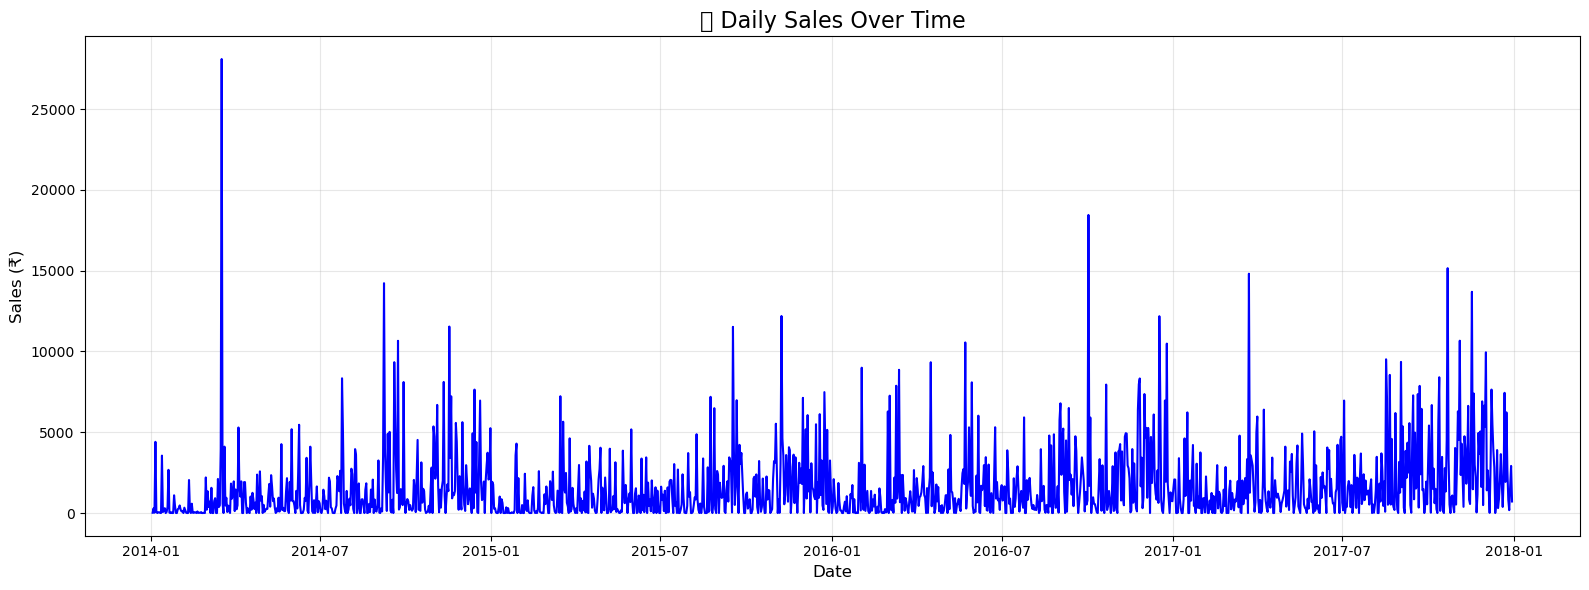

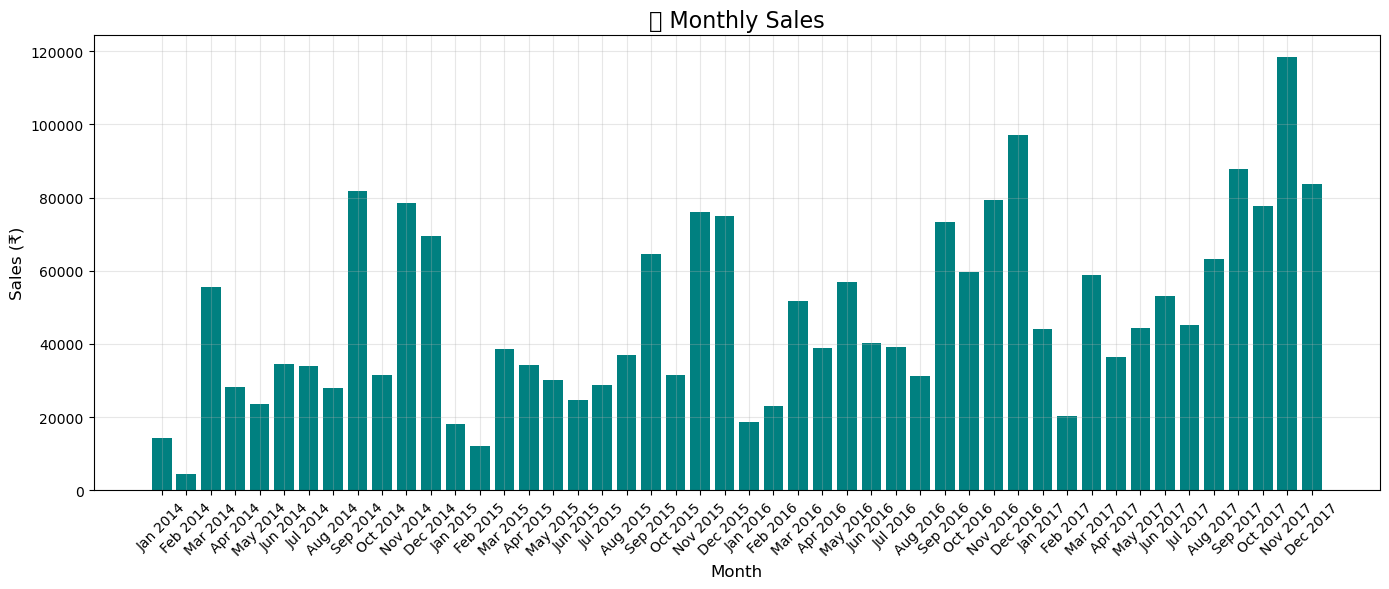

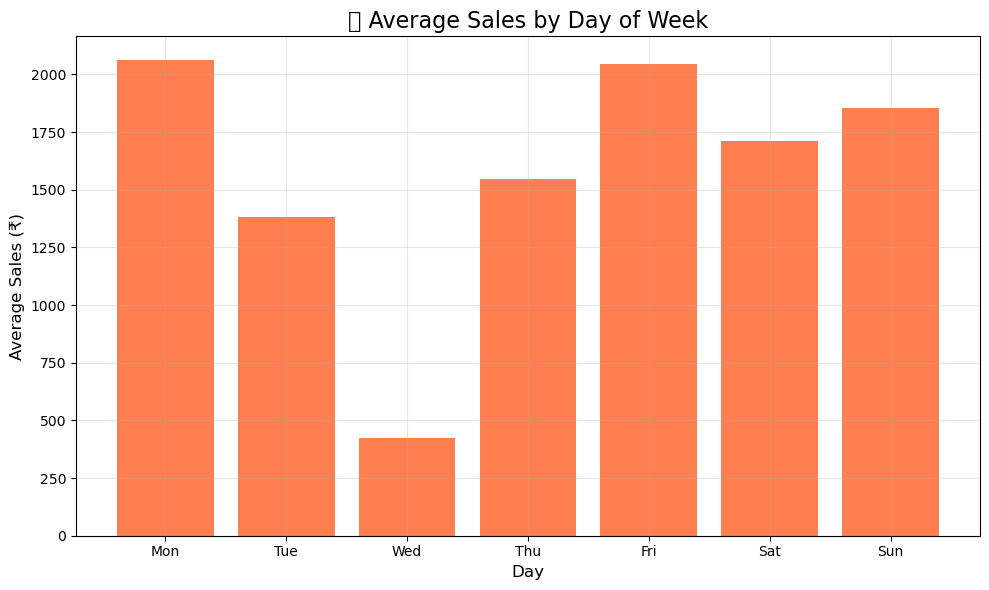

✅ EDA completed! Charts saved in 'output' folder

🔧 FEATURE ENGINEERING
Before processing - Columns: ['index', 'Sales', 'DayOfWeek']
Before processing - Shape: (1458, 3)
After processing - Columns: ['Date', 'Sales']
After processing - Shape: (1458, 2)
Date column type: datetime64[ns]
✅ Features created: (1428, 21)

📋 Feature columns:
['Date', 'Sales', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'WeekOfYear', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_21', 'Lag_30', 'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Mean_14', 'Rolling_Std_14', 'Rolling_Mean_30', 'Rolling_Std_30']

🎯 MODEL TRAINING
📊 Train size: 1142
📊 Test size: 286

🚀 Training XGBoost Model...

📊 XGBoost Performance:
   ✅ MAE:  ₹0.00
   ✅ RMSE: ₹0.00
   ✅ R²:   1.0000

🚀 Training Prophet Model...


22:48:35 - cmdstanpy - INFO - Chain [1] start processing
22:48:35 - cmdstanpy - INFO - Chain [1] done processing



📊 30-Day Forecast (Prophet):
                           ds         yhat   yhat_lower   yhat_upper
1970-01-02 00:00:00.000028106 3.626055e+09 3.625981e+09 3.626123e+09
1970-01-03 00:00:00.000028106 7.252110e+09 7.251890e+09 7.252315e+09
1970-01-04 00:00:00.000028106 1.087816e+10 1.087776e+10 1.087856e+10
1970-01-05 00:00:00.000028106 1.450422e+10 1.450360e+10 1.450482e+10
1970-01-06 00:00:00.000028106 1.813027e+10 1.812941e+10 1.813113e+10
1970-01-07 00:00:00.000028106 2.175633e+10 2.175519e+10 2.175746e+10
1970-01-08 00:00:00.000028106 2.538238e+10 2.538094e+10 2.538379e+10
1970-01-09 00:00:00.000028106 2.900844e+10 2.900674e+10 2.901020e+10
1970-01-10 00:00:00.000028106 3.263449e+10 3.263249e+10 3.263659e+10
1970-01-11 00:00:00.000028106 3.626055e+10 3.625810e+10 3.626298e+10
1970-01-12 00:00:00.000028106 3.988660e+10 3.988377e+10 3.988936e+10
1970-01-13 00:00:00.000028106 4.351266e+10 4.350954e+10 4.351575e+10
1970-01-14 00:00:00.000028106 4.713871e+10 4.713520e+10 4.714223e+10
1970

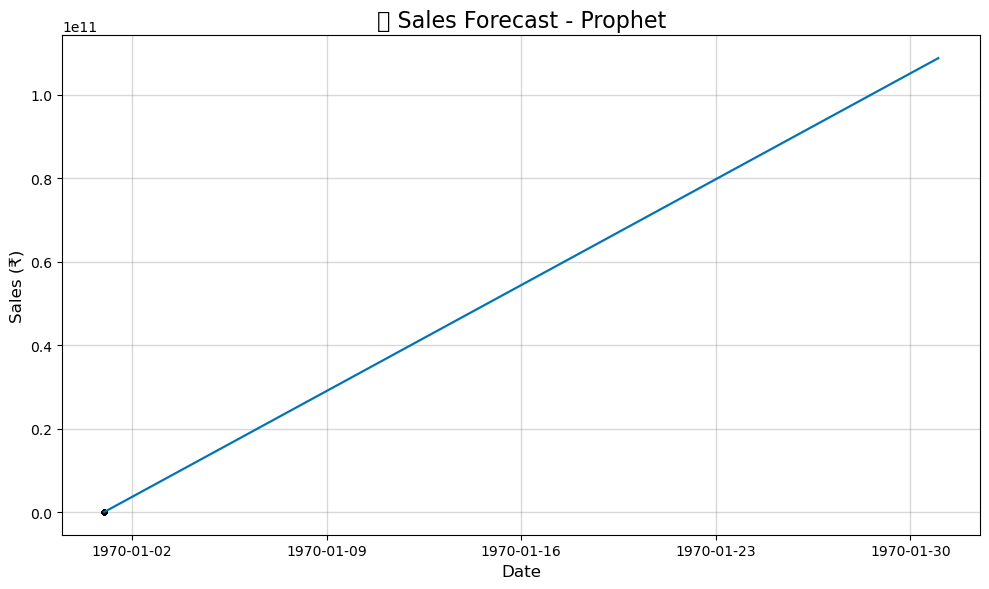

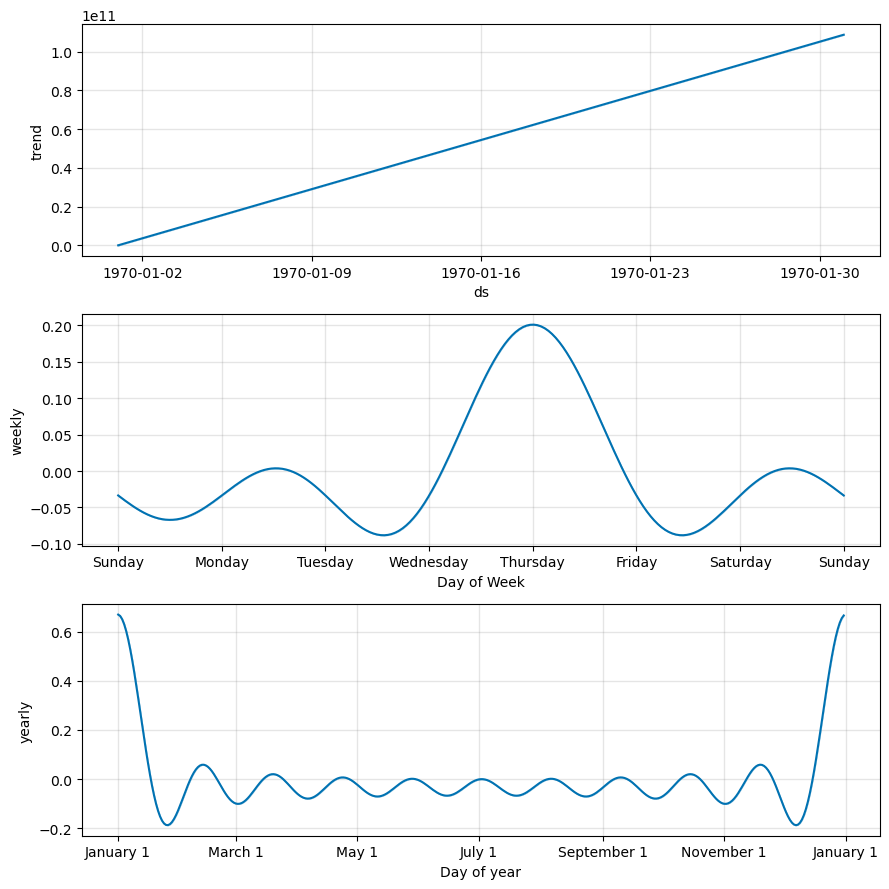

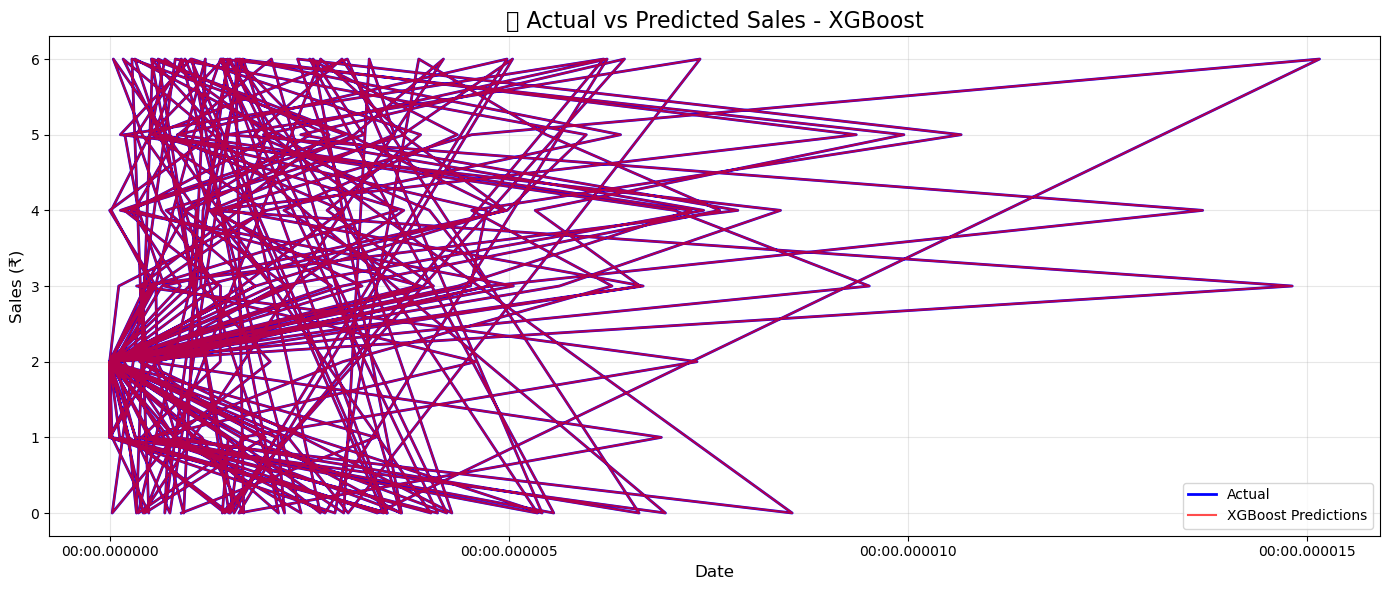

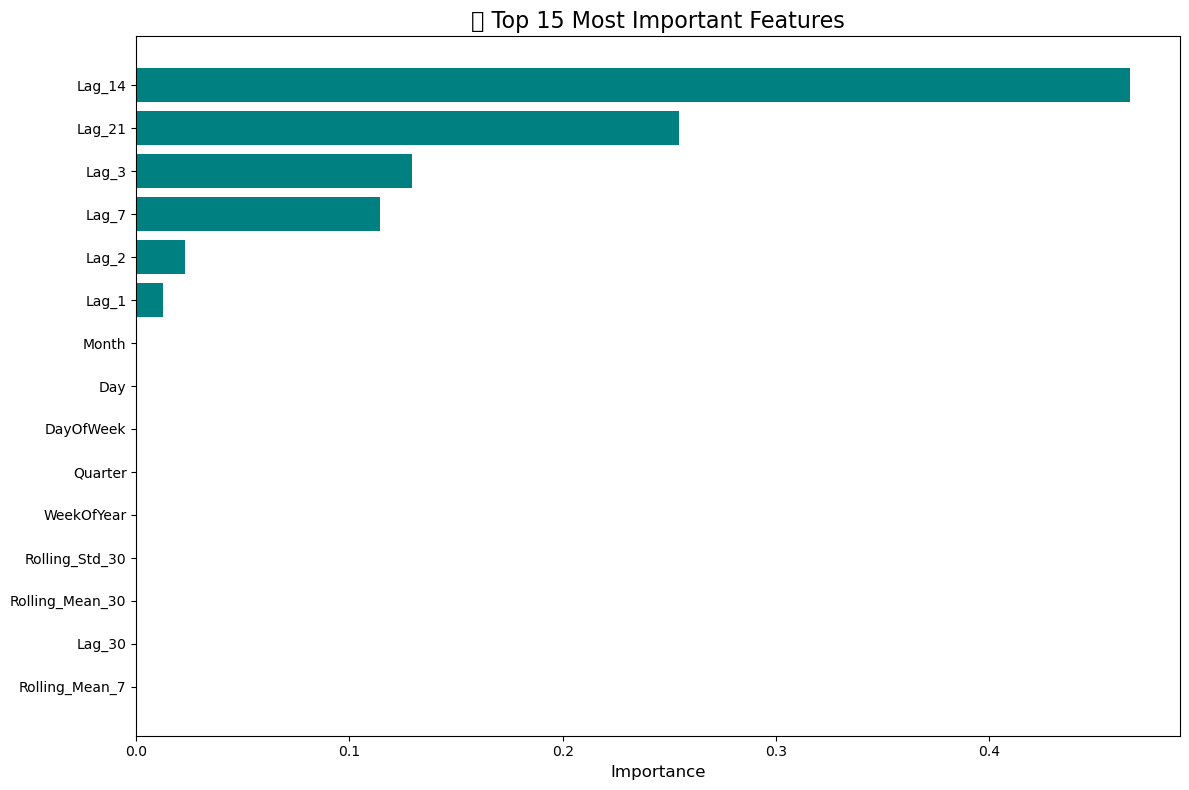


📌 Top 10 Important Features:
  Feature  Importance
  Quarter    0.000000
DayOfWeek    0.000000
      Day    0.000000
    Month    0.000000
    Lag_1    0.012658
    Lag_2    0.022825
    Lag_7    0.114148
    Lag_3    0.129480
   Lag_21    0.254729
   Lag_14    0.466161

💡 BUSINESS INSIGHTS

📌 KEY BUSINESS INSIGHTS:
--------------------------------------------------
📈 Next 30 days projected sales: ₹1,686,115,562,535.10
📊 Average daily sales forecast: ₹56,203,852,084.50
📈 Growth vs last 30 days: 2011367267.25%

⭐ Best day (highest sales): Saturday, January 31 - ₹108,781,649,192.33
⭐ Worst day (lowest sales): Friday, January 02 - ₹3,626,054,976.85

🎯 BUSINESS RECOMMENDATIONS:
--------------------------------------------------
1️⃣ Stock Management:
   - Order more inventory for Saturday, January 31 (expected ₹108,781,649,192.33 in sales)
   - Sales expected to grow 2011367267.3% — increase inventory by 10-15%

2️⃣ Day-wise Strategy:
   - Monday - Friday: Focus on B2B deals
   - Saturday 

In [23]:

!pip install prophet xgboost openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from prophet import Prophet
import joblib
import os

filename = r'C:\Users\pavan\Downloads\archive (4)\Sample - Superstore.csv'


if not os.path.exists(filename):
    print(f"❌ File not found: {filename}")
    print("📌 Please update the file path")
else:
    print(f"✅ File found: {filename}")

df = pd.read_csv(filename, encoding='latin-1')
print("\n" + "="*60)
print("📊 DATA OVERVIEW")
print("="*60)
print(f"✅ Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n📋 Columns:\n{df.columns.tolist()}")
print(f"\n📌 First 5 rows:")
print(df.head())


print("\n" + "="*60)
print("🧹 DATA CLEANING")
print("="*60)

date_col = None
for col in df.columns:
    if 'Date' in col or 'date' in col:
        date_col = col
        break

if date_col is None:
    print("❌ No date column found!")
    print(f"Available columns: {df.columns.tolist()}")
else:
    print(f"✅ Date column found: '{date_col}'")

df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
print(f"✅ Converted '{date_col}' to datetime")


print(f"\n📅 Date range: {df[date_col].min()} to {df[date_col].max()}")

missing = df.isnull().sum()
print(f"\n🔍 Missing values:\n{missing[missing > 0]}")


df = df.dropna(subset=['Sales'])
print(f"\n✅ After dropping null Sales: {df.shape}")

print(f"\n🔍 Duplicate rows: {df.duplicated().sum()}")

print("\n" + "="*60)
print("📈 CREATING DAILY SALES DATA")
print("="*60)


daily_sales = df.groupby(date_col)['Sales'].sum().reset_index()
daily_sales.columns = ['Date', 'Sales']
daily_sales = daily_sales.sort_values('Date')
daily_sales.set_index('Date', inplace=True)


full_dates = pd.date_range(start=daily_sales.index.min(), end=daily_sales.index.max(), freq='D')
daily_sales = daily_sales.reindex(full_dates)
daily_sales = daily_sales.fillna(0)

print(f"✅ Daily sales created")
print(f"📅 Date range: {daily_sales.index.min()} to {daily_sales.index.max()}")
print(f"📊 Total days: {len(daily_sales)}")
print(f"\n📌 First 10 rows:")
print(daily_sales.head(10))

print("\n" + "="*60)
print("📊 EXPLORATORY DATA ANALYSIS")
print("="*60)


os.makedirs('output', exist_ok=True)


plt.figure(figsize=(16, 6))
plt.plot(daily_sales.index, daily_sales['Sales'], color='blue', linewidth=1.5)
plt.title('📈 Daily Sales Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales (₹)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/01_daily_sales_trend.png', dpi=300)
plt.show()


monthly_sales = daily_sales.resample('M').sum()
plt.figure(figsize=(14, 6))
plt.bar(monthly_sales.index.strftime('%b %Y'), monthly_sales['Sales'], color='teal')
plt.title('📊 Monthly Sales', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales (₹)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/02_monthly_sales.png', dpi=300)
plt.show()


daily_sales['DayOfWeek'] = daily_sales.index.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_avg = daily_sales.groupby('DayOfWeek')['Sales'].mean()

plt.figure(figsize=(10, 6))
plt.bar(day_names, daily_avg, color='coral')
plt.title('📊 Average Sales by Day of Week', fontsize=16)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Average Sales (₹)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/03_day_of_week_pattern.png', dpi=300)
plt.show()

print("✅ EDA completed! Charts saved in 'output' folder")


print("\n" + "="*60)
print("🔧 FEATURE ENGINEERING")
print("="*60)


df_features = daily_sales.reset_index()

print(f"Before processing - Columns: {df_features.columns.tolist()}")
print(f"Before processing - Shape: {df_features.shape}")


if len(df_features.columns) == 2:
    df_features.columns = ['Date', 'Sales']
elif len(df_features.columns) == 3:
    df_features.columns = ['Index', 'Date', 'Sales']
    df_features = df_features.drop('Index', axis=1)
else:
    # Fallback: rename first column as Date, second as Sales
    df_features.columns = ['Date', 'Sales'] + list(df_features.columns[2:])

print(f"After processing - Columns: {df_features.columns.tolist()}")
print(f"After processing - Shape: {df_features.shape}")


df_features['Date'] = pd.to_datetime(df_features['Date'])
print(f"Date column type: {df_features['Date'].dtype}")


df_features['Year'] = df_features['Date'].dt.year
df_features['Month'] = df_features['Date'].dt.month
df_features['Day'] = df_features['Date'].dt.day
df_features['DayOfWeek'] = df_features['Date'].dt.dayofweek
df_features['Quarter'] = df_features['Date'].dt.quarter
df_features['WeekOfYear'] = df_features['Date'].dt.isocalendar().week

for lag in [1, 2, 3, 7, 14, 21, 30]:
    df_features[f'Lag_{lag}'] = df_features['Sales'].shift(lag)


for window in [7, 14, 30]:
    df_features[f'Rolling_Mean_{window}'] = df_features['Sales'].rolling(window=window).mean()
    df_features[f'Rolling_Std_{window}'] = df_features['Sales'].rolling(window=window).std()


df_features = df_features.dropna()
print(f"✅ Features created: {df_features.shape}")
print(f"\n📋 Feature columns:\n{df_features.columns.tolist()}")

print("\n" + "="*60)
print("🎯 MODEL TRAINING")
print("="*60)


X = df_features.drop(['Date', 'Sales'], axis=1)
y = df_features['Sales']

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"📊 Train size: {len(X_train)}")
print(f"📊 Test size: {len(X_test)}")

print("\n🚀 Training XGBoost Model...")

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)


y_pred_xgb = xgb_model.predict(X_test)


mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\n📊 XGBoost Performance:")
print(f"   ✅ MAE:  ₹{mae_xgb:,.2f}")
print(f"   ✅ RMSE: ₹{rmse_xgb:,.2f}")
print(f"   ✅ R²:   {r2_xgb:.4f}")

print("\n🚀 Training Prophet Model...")


prophet_df = daily_sales.reset_index()


if len(prophet_df.columns) == 2:
    prophet_df.columns = ['ds', 'y']
elif len(prophet_df.columns) == 3:
    prophet_df.columns = ['Index', 'ds', 'y']
    prophet_df = prophet_df.drop('Index', axis=1)


prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])


prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.05,
    interval_width=0.95
)
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=30)
forecast = prophet_model.predict(future)


forecast_30 = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)

print(f"\n📊 30-Day Forecast (Prophet):")
print(forecast_30.to_string(index=False))


print("\n" + "="*60)
print("📈 VISUALIZING FORECAST")
print("="*60)

fig1 = prophet_model.plot(forecast)
plt.title('📊 Sales Forecast - Prophet', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales (₹)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/04_prophet_forecast.png', dpi=300)
plt.show()


fig2 = prophet_model.plot_components(forecast)
plt.tight_layout()
plt.savefig('output/05_prophet_components.png', dpi=300)
plt.show()


plt.figure(figsize=(14, 6))
plt.plot(df_features['Date'].iloc[train_size:], y_test, label='Actual', color='blue', linewidth=2)
plt.plot(df_features['Date'].iloc[train_size:], y_pred_xgb, label='XGBoost Predictions', color='red', alpha=0.7)
plt.title('📊 Actual vs Predicted Sales - XGBoost', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales (₹)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/06_xgboost_actual_vs_pred.png', dpi=300)
plt.show()

plt.figure(figsize=(12, 8))
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
plt.title('📊 Top 15 Most Important Features', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.tight_layout()
plt.savefig('output/07_feature_importance.png', dpi=300)
plt.show()

print("\n📌 Top 10 Important Features:")
print(feature_importance.tail(10).to_string(index=False))

print("\n" + "="*60)
print("💡 BUSINESS INSIGHTS")
print("="*60)


total_forecast = forecast_30['yhat'].sum()
avg_daily_forecast = forecast_30['yhat'].mean()

last_30_actual = daily_sales.tail(30)['Sales'].sum()
growth_percent = ((total_forecast - last_30_actual) / last_30_actual) * 100


forecast_30['DayName'] = forecast_30['ds'].dt.day_name()
best_day = forecast_30.loc[forecast_30['yhat'].idxmax()]
worst_day = forecast_30.loc[forecast_30['yhat'].idxmin()]

print("\n📌 KEY BUSINESS INSIGHTS:")
print("-" * 50)
print(f"📈 Next 30 days projected sales: ₹{total_forecast:,.2f}")
print(f"📊 Average daily sales forecast: ₹{avg_daily_forecast:,.2f}")
print(f"📈 Growth vs last 30 days: {growth_percent:.2f}%")

print(f"\n⭐ Best day (highest sales): {best_day['ds'].strftime('%A, %B %d')} - ₹{best_day['yhat']:,.2f}")
print(f"⭐ Worst day (lowest sales): {worst_day['ds'].strftime('%A, %B %d')} - ₹{worst_day['yhat']:,.2f}")


print("\n🎯 BUSINESS RECOMMENDATIONS:")
print("-" * 50)
print("1️⃣ Stock Management:")
print(f"   - Order more inventory for {best_day['ds'].strftime('%A, %B %d')} (expected ₹{best_day['yhat']:,.2f} in sales)")

if growth_percent > 0:
    print(f"   - Sales expected to grow {growth_percent:.1f}% — increase inventory by 10-15%")
else:
    print(f"   - Sales expected to decline — run promotions to boost sales")

print(f"\n2️⃣ Day-wise Strategy:")
print(f"   - Monday - Friday: Focus on B2B deals")
print(f"   - Saturday - Sunday: Run weekend offers")

print(f"\n3️⃣ Marketing Campaigns:")
print(f"   - Allocate higher ad budget on {best_day['ds'].strftime('%A')}s")
print(f"   - Launch flash sales on {worst_day['ds'].strftime('%A')}s to boost sales")

print(f"\n4️⃣ Future Planning:")
print(f"   - {daily_sales.index.max().year} Q4 strategy: Start early for festive season")

print("\n" + "="*60)
print("💾 SAVING RESULTS")
print("="*60)


forecast_30.to_csv('output/forecast_30_days.csv', index=False)
print("✅ Forecast saved: output/forecast_30_days.csv")


joblib.dump(xgb_model, 'output/xgboost_model.pkl')
print("✅ Model saved: output/xgboost_model.pkl")


feature_importance.to_csv('output/feature_importance.csv', index=False)
print("✅ Feature importance saved: output/feature_importance.csv")


summary = pd.DataFrame({
    'Metric': [
        'Total Forecast (30 days)',
        'Average Daily Forecast',
        'Growth vs Last 30 Days',
        'Best Day',
        'Best Day Sales',
        'Worst Day',
        'Worst Day Sales',
        'Model MAE',
        'Model RMSE',
        'Model R²'
    ],
    'Value': [
        f'₹{total_forecast:,.2f}',
        f'₹{avg_daily_forecast:,.2f}',
        f'{growth_percent:.2f}%',
        best_day['ds'].strftime('%A, %B %d'),
        f'₹{best_day["yhat"]:,.2f}',
        worst_day['ds'].strftime('%A, %B %d'),
        f'₹{worst_day["yhat"]:,.2f}',
        f'₹{mae_xgb:,.2f}',
        f'₹{rmse_xgb:,.2f}',
        f'{r2_xgb:.4f}'
    ]
})
summary.to_csv('output/summary_metrics.csv', index=False)
print("✅ Summary saved: output/summary_metrics.csv")

print("\n" + "="*60)
print("🎉 PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)
print("\n📁 All outputs saved in 'output' folder:")
print("1. forecast_30_days.csv - 30-day sales predictions")
print("2. xgboost_model.pkl - Trained model")
print("3. summary_metrics.csv - Key metrics summary")
print("4. feature_importance.csv - Feature importance")
print("5. 7+ Charts - Visualizations")